## Cargar conjunto de datos

In [ ]:
%pip install shap

- Datasets
    - CSE-CIC-IDS2018: https://data.mendeley.com/datasets/29hdbdzx2r/1


Primeramente se cargan las bibliotecas qu se usarán.

In [1]:
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

Para cargar los datos se utiliza la ruta raíz dónde se encuentran el conjunto de datos con todos los archivos .csv, se van cargando y concatenando para formar el conjunto de datos completo.

In [2]:
# Colocar la ruta de los archivos CSV
ruta = r"C:\Users\Usuario\OneDrive\Documentos\Maestría\Redes\Proyecto final - Lab\CSE-CIC-IDS2018-Attacks"   

# Buscar todos los CSV
archivos = glob.glob(os.path.join(ruta, "*.csv"))

# Leerlos en una lista de DataFrames
archivos_leidos = []

for archivo in archivos:
    archivo_leido = pd.read_csv(archivo)
    archivos_leidos.append(archivo_leido)

df = pd.concat(archivos_leidos, ignore_index=True)

# Liberar memoria eliminando la lista de DataFrames individuales
del archivos_leidos

Se estandarizan los nombres de las columnas y se reemplazan los espacios por _.

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

In [4]:
# Mostrar las columnas del DataFrame para verificar la normalización
print(df.columns)

Index(['dst_port', 'protocol', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts',
       'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max',
       'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std',
       'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean',
       'bwd_pkt_len_std', 'flow_byts_s', 'flow_pkts_s', 'flow_iat_mean',
       'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_tot',
       'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min',
       'bwd_iat_tot', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max',
       'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags',
       'bwd_urg_flags', 'fwd_header_len', 'bwd_header_len', 'fwd_pkts_s',
       'bwd_pkts_s', 'pkt_len_min', 'pkt_len_max', 'pkt_len_mean',
       'pkt_len_std', 'pkt_len_var', 'fin_flag_cnt', 'syn_flag_cnt',
       'rst_flag_cnt', 'psh_flag_cnt', 'ack_flag_cnt', 'urg_flag_cnt',
       'cwe_flag_count', 'ece_flag_cnt', 'down_up_ratio', 'pkt_size_avg',
       'fwd_seg_siz

El conjunto de datos cuenta con 9625148 filas y 79 columnas.

In [5]:
df

,dst_port,protocol,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,22,6,257024,11,11,1249,1969.0,736,0,113.545455,...,20,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,0,0,112641101,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56300000.0,84.145707,56300000.0,56300000.0,Benign
2,0,0,112639047,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56300000.0,96.873629,56300000.0,56300000.0,Benign
3,0,0,112640744,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56300000.0,7.071068,56300000.0,56300000.0,Benign
4,22,6,5707641,14,11,1123,1969.0,648,0,80.214286,...,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9625143,445,6,764295,2,2,0,0.0,0,0,0.000000,...,28,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
9625144,8545,6,21,1,1,0,0.0,0,0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
9625145,12515,6,147551,2,1,0,0.0,0,0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
9625146,6889,6,106905,2,1,0,0.0,0,0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign


## Exploración inicial de los datos

### Revisión general

In [6]:
# Obtener una vista general
print("Vista general")
print(df.info())

Vista general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9625148 entries, 0 to 9625147
Data columns (total 79 columns):
 #   Column             Dtype  
---  ------             -----  
 0   dst_port           int64  
 1   protocol           int64  
 2   flow_duration      int64  
 3   tot_fwd_pkts       int64  
 4   tot_bwd_pkts       int64  
 5   totlen_fwd_pkts    int64  
 6   totlen_bwd_pkts    float64
 7   fwd_pkt_len_max    int64  
 8   fwd_pkt_len_min    int64  
 9   fwd_pkt_len_mean   float64
 10  fwd_pkt_len_std    float64
 11  bwd_pkt_len_max    int64  
 12  bwd_pkt_len_min    int64  
 13  bwd_pkt_len_mean   float64
 14  bwd_pkt_len_std    float64
 15  flow_byts_s        int64  
 16  flow_pkts_s        int64  
 17  flow_iat_mean      float64
 18  flow_iat_std       float64
 19  flow_iat_max       float64
 20  flow_iat_min       float64
 21  fwd_iat_tot        float64
 22  fwd_iat_mean       float64
 23  fwd_iat_std        float64
 24  fwd_iat_max        float64
 25  fwd_

Las estadísticas muestran medianas bajas en comparación con máximos atlos, lo cual es un indicio de distribuciones sesgadas y presencia de outliers. Este dato es normal al tener tráfico benigno y ataques de red. Muchos columnas en sus percentiles de 25% y 50% se encuentran con valores en 0 o valores muy pequeños pero la desviación estándar y el máximo tienen valores muy superiores, este dato indica la presencia de valores atípicos.

In [7]:
df.describe()

,dst_port,protocol,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,...,fwd_act_data_pkts,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
count,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,...,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06,9.625148e+06
mean,1.014429e+04,8.123769e+00,1.057733e+07,3.556911e+01,5.925430e+00,1.369280e+03,4.514353e+03,2.154020e+02,8.733470e+00,5.168975e+01,...,3.207856e+01,1.966091e+01,8.494940e+04,3.962741e+04,1.356453e+05,6.002885e+04,4.983568e+06,2.270448e+05,5.339880e+06,4.710918e+06
std,1.971508e+04,4.469866e+00,6.709330e+08,1.974306e+03,1.640883e+02,6.600396e+04,2.358357e+05,3.302343e+02,2.356418e+01,6.742416e+01,...,1.973367e+03,8.115200e+00,1.424316e+06,8.171935e+05,1.882846e+06,1.225343e+06,2.354642e+08,1.511926e+08,5.874528e+08,2.394620e+07
min,0.000000e+00,0.000000e+00,-9.190110e+11,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,6.000000e+00,6.320000e+02,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,6.000000e+00,1.989100e+04,2.000000e+00,1.000000e+00,4.000000e+01,9.500000e+01,3.800000e+01,0.000000e+00,3.300000e+01,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.389000e+03,6.000000e+00,3.701258e+06,5.000000e+00,4.000000e+00,5.120000e+02,4.880000e+02,3.260000e+02,0.000000e+00,7.900000e+01,...,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.700000e+01,1.200000e+08,3.096290e+05,1.231180e+05,4.176568e+07,1.563604e+08,6.444000e+04,1.460000e+03,1.652931e+04,...,3.096280e+05,4.800000e+01,1.140000e+08,7.495336e+07,1.140000e+08,1.140000e+08,3.955714e+11,2.432682e+11,9.797810e+11,5.196000e+10


In [8]:
# Contar valores únicos por columna
print("Valores únicos por columna:")
print(df.nunique())

Valores únicos por columna:
dst_port           62539
protocol               3
flow_duration    2505195
tot_fwd_pkts        4198
tot_bwd_pkts        2437
                  ...   
idle_mean         576459
idle_std          355991
idle_max          431203
idle_min          493586
label                 15
Length: 79, dtype: int64


In [9]:
# Cantidad de filas
print("Cantidad de filas:")
df.shape[0]

Cantidad de filas:


9625148

Los tipos de datos nos proporcionan la información sobre la cantidad de tipos de datos presentes en el cojunto de datos. En este caso, existen 43 columnas de tipo entero, 35 columnas de tipo flotante y 1 de tipo string que sería la etiqueta.

In [10]:
# Información general del dataset
print('Tipos de datos:')
print(df.dtypes.value_counts())
print(f'\nValores faltantes totales: {df.isnull().sum().sum()}')

# Variables categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\nVariables categóricas: {cat_cols}')
for col in cat_cols:
    if col != 'label':
        print(f'  {col}: {df[col].nunique()} valores únicos')

Tipos de datos:
int64      43
float64    35
object      1
Name: count, dtype: int64

Valores faltantes totales: 0

Variables categóricas: ['label']


### Distribución de clases y balance

El conjunto de datos demuestra un gran desiquilibrio entre el tráfico benigno y ataques, lo cual corresponde a un resultado normal para el tráfico de red. 

Distribución de etiquetas (tipos de tráfico):
label
Benign                      6876913
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


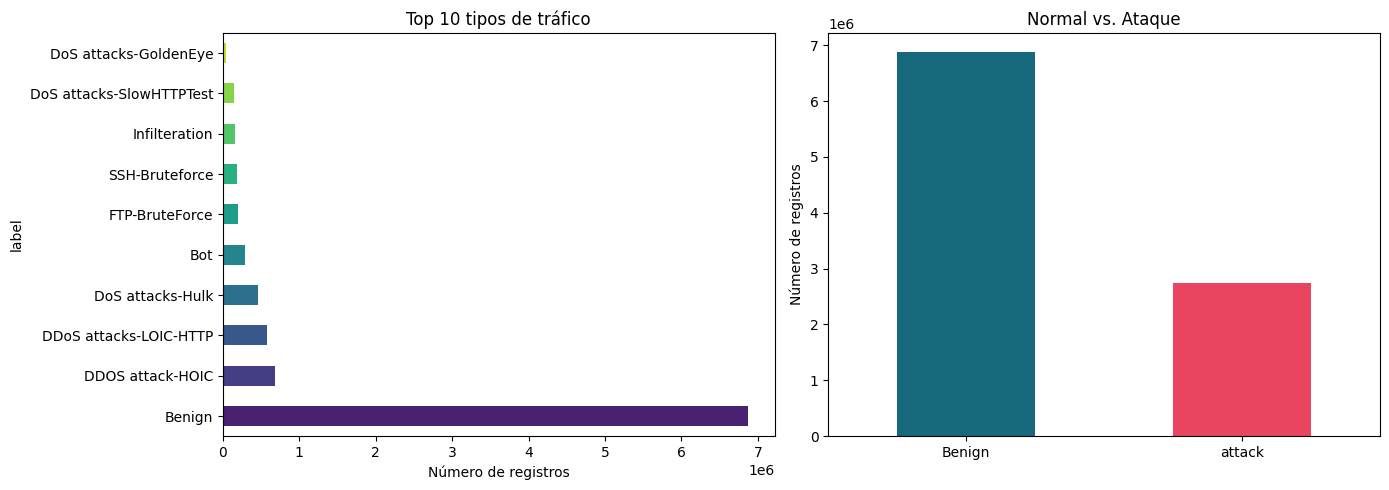

In [11]:
# Distribución de las etiquetas
print('Distribución de etiquetas (tipos de tráfico):')
label_counts = df['label'].value_counts()
print(label_counts)

# Crear columna binaria: normal vs. ataque
df['attack_type'] = df['label'].apply(lambda x: 'Benign' if x == 'Benign' else 'attack')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Top 10 tipos de tráfico
label_counts.head(10).plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', 10))
axes[0].set_title('Top 10 tipos de tráfico')
axes[0].set_xlabel('Número de registros')

# Gráfico 2: Normal vs. Ataque
df['attack_type'].value_counts().plot(kind='bar', ax=axes[1], color=['#16697A', '#E94560'])
axes[1].set_title('Normal vs. Ataque')
axes[1].set_xlabel('')
axes[1].set_ylabel('Número de registros')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

df.drop(columns=['attack_type'], inplace=True)

### Estadísticas descriptivas

Estos altos valores de coeficiente de varianza son un indicativo de que las características tienen muchas variaciones a su media, los cuales pueden ser señales de comportamientos ánmola asociado a los ataques. Esto puede ser un problema en modelos que se basan en distancia o la media como KNN o SVM, ya que estos valores outliers suelen sesgar los resultados si no se son tratados adecuadamente con técnicas de escalado o winsorizar los percentiles. 

In [12]:
# Solo columnas numéricas
cols_sin_label = [c for c in df.columns if c != "label"]
numeric_cols = df[cols_sin_label].select_dtypes(include=[np.number]).columns.tolist()
print(f'Features numéricas: {len(numeric_cols)}')

# Estadísticas descriptivas
stats = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
stats['cv'] = stats['std'] / stats['mean'].replace(0, np.nan)  # coeficiente de variación
stats = stats.round(4)

# Mostrar las 15 features con mayor variabilidad (coef. de variación)
print('\nTop 20 features con mayor variabilidad (CV = std/media):')
print(stats['cv'].dropna().sort_values(ascending=False).head(20).to_frame().to_string())

Features numéricas: 78

Top 20 features con mayor variabilidad (CV = std/media):
                         cv
idle_std           665.9155
flow_iat_std       281.2474
fwd_iat_std        266.0798
flow_iat_min       252.5532
fwd_iat_min        245.2921
fwd_iat_max        110.0627
idle_max           110.0124
flow_iat_max       106.3107
flow_iat_mean      105.4321
fwd_iat_mean        98.8390
fwd_iat_tot         65.3614
flow_duration       63.4312
fwd_act_data_pkts   61.5167
cwe_flag_count      59.4892
fwd_urg_flags       59.4892
tot_fwd_pkts        55.5062
subflow_fwd_pkts    55.5062
totlen_bwd_pkts     52.2413
subflow_bwd_byts    52.2386
subflow_fwd_byts    48.2034


## Limpieza

### Revisión de duplicados

Para este caso, se revisará si en el conjunto de datos existen filas completamente iguales.

In [13]:
# Verificar duplicados en el DataFrame True / False
duplicados = df.duplicated()

# Aplicar máscara
df_duplicados = df[duplicados]

# Mostrar las filas duplicadas
df_duplicados

,dst_port,protocol,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
118,23,6,20,1,1,0,0.0,0,0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
134,445,6,18,1,1,0,0.0,0,0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
150,445,6,17,1,1,0,0.0,0,0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
157,445,6,17,1,1,0,0.0,0,0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
165,445,6,18,1,1,0,0.0,0,0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9625142,8911,6,141449,2,1,0,0.0,0,0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
9625143,445,6,764295,2,2,0,0.0,0,0,0.0,...,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
9625144,8545,6,21,1,1,0,0.0,0,0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
9625145,12515,6,147551,2,1,0,0.0,0,0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


Se encontraron 4442127 filas que comparten datos completamente iguales, por lo tanto esto indicaría que existe gran redudancia por lo que se decide solo dejar la primer coincidentia de las filas duplicadas.

In [14]:
print("Eliminar de duplicados, manteniendo la primera aparición.")
df.drop_duplicates(keep='first', inplace=True)

Eliminar de duplicados, manteniendo la primera aparición.


In [15]:
# Verificar duplicados en el DataFrame True / False
duplicados = df.duplicated()

# Aplicar máscara
df_duplicados = df[duplicados]

# Mostrar las filas duplicadas
df_duplicados

,dst_port,protocol,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label


Al final se eliminaron todas las duplicadas, dejando a un conjunto de datos sin duplicados de 5183021 filas totales.

In [16]:
# Cantidad de filas
print("Cantidad de filas:")
df.shape[0]

Cantidad de filas:


5183021

### Revisión nulos

El conjunto de datos no presenta datos nulos.

In [17]:
print("Revisión de nulos")
print(df.isna().sum())

Revisión de nulos
dst_port         0
protocol         0
flow_duration    0
tot_fwd_pkts     0
tot_bwd_pkts     0
                ..
idle_mean        0
idle_std         0
idle_max         0
idle_min         0
label            0
Length: 79, dtype: int64


### Revisión de negativos

In [18]:
cols_negativas = df.drop(columns=['label']).columns[(df.drop(columns=['label']) < 0).any()]

print("Columnas con valores negativos:")
print(cols_negativas.tolist())

Columnas con valores negativos:
['flow_duration', 'flow_byts_s', 'flow_pkts_s', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_tot', 'fwd_iat_mean', 'fwd_iat_max', 'fwd_iat_min', 'init_fwd_win_byts', 'init_bwd_win_byts']


In [19]:
filas_con_negativos = df[df[cols_negativas] < 0].any(axis=1)
df_filas_negativas = df[filas_con_negativos]

df_filas_negativas

,dst_port,protocol,flow_duration,tot_fwd_pkts,tot_bwd_pkts,totlen_fwd_pkts,totlen_bwd_pkts,fwd_pkt_len_max,fwd_pkt_len_min,fwd_pkt_len_mean,...,fwd_seg_size_min,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
1,0,0,112641101,3,0,0,0.0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,84.145707,56300000.0,56300000.0,Benign
2,0,0,112639047,3,0,0,0.0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,96.873629,56300000.0,56300000.0,Benign
3,0,0,112640744,3,0,0,0.0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,7.071068,56300000.0,56300000.0,Benign
5,0,0,112640662,3,0,0,0.0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,11.313709,56300000.0,56300000.0,Benign
16,0,0,112640601,3,0,0,0.0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,56300000.0,19.091883,56300000.0,56300000.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9625054,53,17,148201,2,2,74,268.0,37,37,37.0,...,8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
9625057,53,17,18562,1,1,32,88.0,32,32,32.0,...,8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
9625066,53,17,1872,1,1,34,64.0,34,34,34.0,...,8,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
9625079,0,0,59149887,2,0,0,0.0,0,0,0.0,...,0,0.0,0.0,0.0,0.0,59100000.0,0.000000,59100000.0,59100000.0,Benign


In [20]:
#df = df[(df[cols_negativas] >= 0).all(axis=1)]

### Correlación entre características

La identificación de pares altamente relación (con puntaje mayor a 0.85) dio como resultado 87 pares, los cuales muestran una redundancia sumamente fuerte entre las características de conteo, tamaños de paquetes, tiempos inter-arribo y flags. Muchas de estas columnas son derivadas o duplicados directo de otras que resultan ser más informativa. Por lo tanto, estos resultados nos indican que es necesario eliminarlas para evitar la redundancia de información al entrenar los modelos.

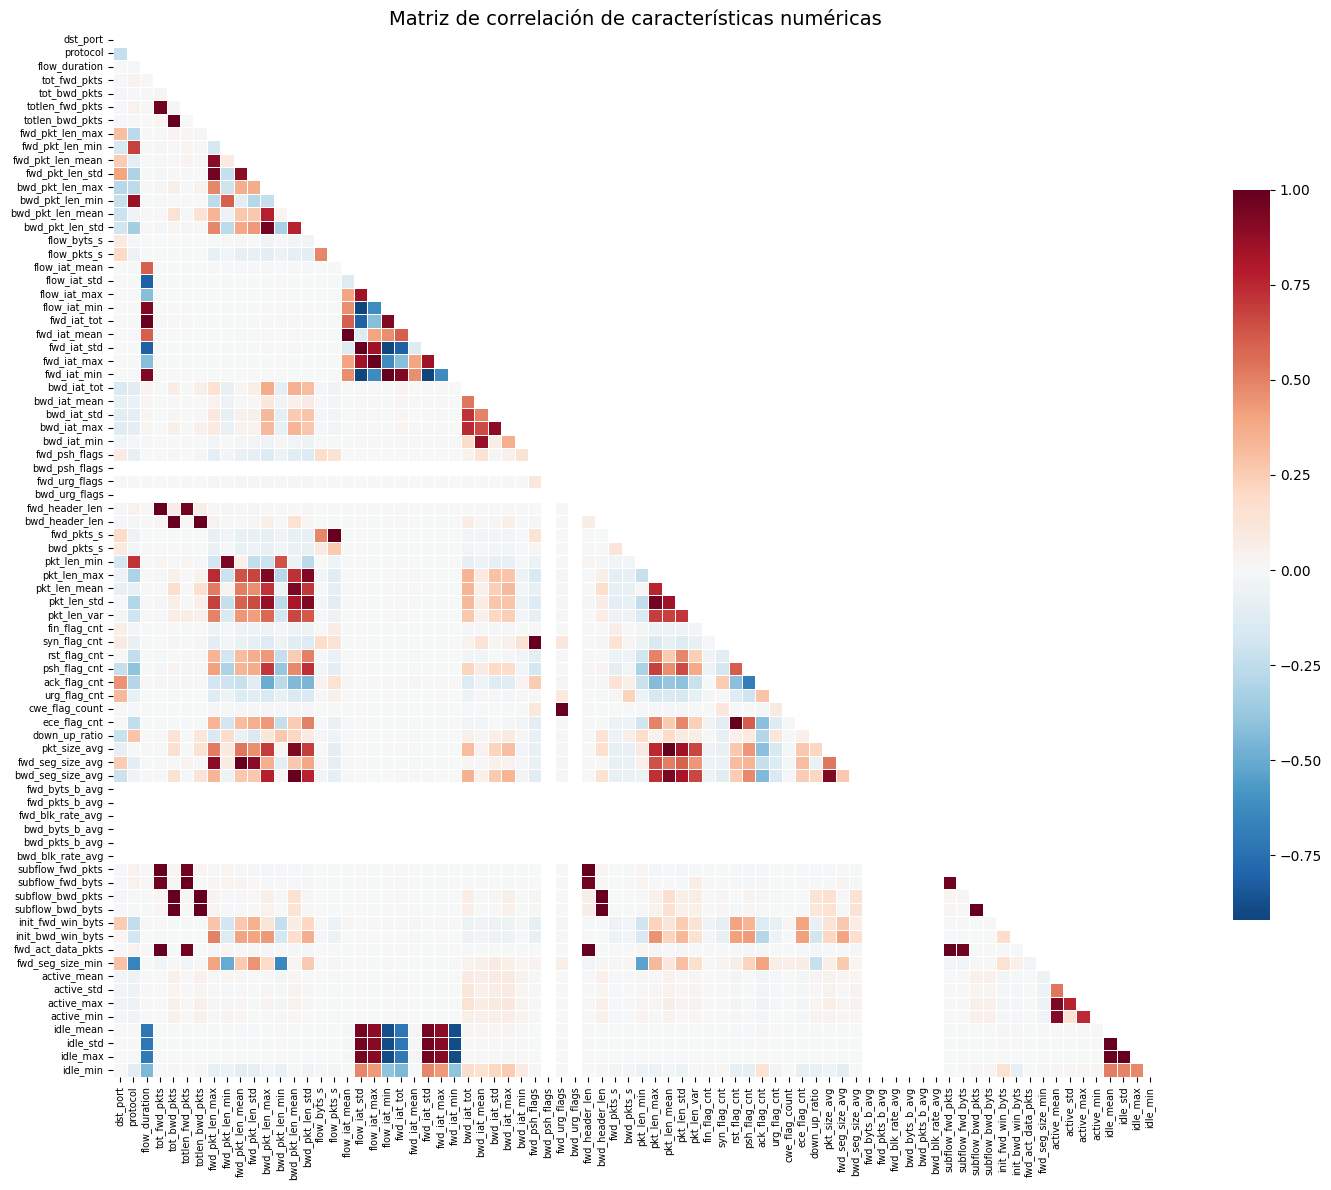


Pares con correlación > 0.85: 87
  protocol — bwd_pkt_len_min: 0.865
  flow_duration — flow_iat_min: 0.922
  flow_duration — fwd_iat_tot: 1.0
  flow_duration — fwd_iat_min: 0.922
  tot_fwd_pkts — totlen_fwd_pkts: 0.966
  tot_fwd_pkts — fwd_header_len: 0.997
  tot_fwd_pkts — subflow_fwd_pkts: 1.0
  tot_fwd_pkts — subflow_fwd_byts: 0.966
  tot_fwd_pkts — fwd_act_data_pkts: 1.0
  tot_bwd_pkts — totlen_bwd_pkts: 0.997
  tot_bwd_pkts — bwd_header_len: 0.998
  tot_bwd_pkts — subflow_bwd_pkts: 1.0
  tot_bwd_pkts — subflow_bwd_byts: 0.997
  totlen_fwd_pkts — fwd_header_len: 0.961
  totlen_fwd_pkts — subflow_fwd_pkts: 0.966
  totlen_fwd_pkts — subflow_fwd_byts: 1.0
  totlen_fwd_pkts — fwd_act_data_pkts: 0.966
  totlen_bwd_pkts — bwd_header_len: 0.997
  totlen_bwd_pkts — subflow_bwd_pkts: 0.997
  totlen_bwd_pkts — subflow_bwd_byts: 1.0
  fwd_pkt_len_max — fwd_pkt_len_mean: 0.895
  fwd_pkt_len_max — fwd_pkt_len_std: 0.955
  fwd_pkt_len_max — fwd_seg_size_avg: 0.895
  fwd_pkt_len_min — pkt_len_mi

In [21]:
# Seleccionar solo las columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calcular la matriz de correlación
corr_matrix = df[num_cols].corr()

# Visualizar
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            xticklabels=True, yticklabels=True)
plt.title('Matriz de correlación de características numéricas', fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Identificar pares altamente correlacionados
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                              round(corr_matrix.iloc[i, j], 3)))

print(f'\nPares con correlación > 0.85: {len(high_corr)}')
for c1, c2, corr in high_corr:
    print(f'  {c1} — {c2}: {corr}')

In [22]:
cols_a_eliminar = [
    # Pares con tot_fwd_pkts
    "totlen_fwd_pkts", "fwd_header_len", "subflow_fwd_pkts",
    "subflow_fwd_byts", "fwd_act_data_pkts",

    # Pares con tot_bwd_pkts
    "totlen_bwd_pkts", "bwd_header_len", "subflow_bwd_pkts",
    "subflow_bwd_byts",

    # Pares con flow_duration / flow_iat / fwd_iat
    "flow_iat_min", "fwd_iat_tot", "fwd_iat_min",

    # Pares con pkt_len redundantes
    "fwd_pkt_len_mean", "fwd_pkt_len_std", "fwd_seg_size_avg",
    "bwd_pkt_len_mean", "bwd_pkt_len_std", "bwd_seg_size_avg",
    "pkt_size_avg",

    # Flags redundantes
    "fwd_psh_flags", "fwd_urg_flags", "rst_flag_cnt",

    # Otros redundantes
    "bwd_pkt_len_min"
]

df.drop(columns=cols_a_eliminar, inplace=True)

In [23]:
# Mostrar las columnas del DataFrame
print(df.columns)

Index(['dst_port', 'protocol', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts',
       'fwd_pkt_len_max', 'fwd_pkt_len_min', 'bwd_pkt_len_max', 'flow_byts_s',
       'flow_pkts_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max',
       'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'bwd_iat_tot',
       'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min',
       'bwd_psh_flags', 'bwd_urg_flags', 'fwd_pkts_s', 'bwd_pkts_s',
       'pkt_len_min', 'pkt_len_max', 'pkt_len_mean', 'pkt_len_std',
       'pkt_len_var', 'fin_flag_cnt', 'syn_flag_cnt', 'psh_flag_cnt',
       'ack_flag_cnt', 'urg_flag_cnt', 'cwe_flag_count', 'ece_flag_cnt',
       'down_up_ratio', 'fwd_byts_b_avg', 'fwd_pkts_b_avg', 'fwd_blk_rate_avg',
       'bwd_byts_b_avg', 'bwd_pkts_b_avg', 'bwd_blk_rate_avg',
       'init_fwd_win_byts', 'init_bwd_win_byts', 'fwd_seg_size_min',
       'active_mean', 'active_std', 'active_max', 'active_min', 'idle_mean',
       'idle_std', 'idle_max', 'idle_min', 'label'],
      dtype=

### Selección de características

La revisión de valores atípicos con boxplots demuestra que las características seleccionadas del conjunto de datos cuentan con valores anómalos en el tráfico de red. Columnas como puertos, duración del flujo y el número de paquetes (dst_port, flow_duration, tot_fwd_pkts y tot_bwd_pkts) presentan valores atípicos concentrados en ataques como DoS, DDoS y de fuerza bruta. Este comportamiento también se muestra en las variables de longitud de paquetes, tasas de bytes, paquetes en segundo plano (fwd_pkt_len_max, bwd_pkt_len_max, pkt_len_max, pkt_len_mean, pkt_len_std, pkt_len_var— así como en las tasas de transmisión flow_byts_s, flow_pkts_s, fwd_pkts_s y bwd_pkts_s) y en las estadísticas de tiempos entre llegadas (IAT) como flow_iat_mean, flow_iat_std, flow_iat_max, fwd_iat_mean, fwd_iat_std, fwd_iat_max, bwd_iat_tot, bwd_iat_std, bwd_iat_max y bwd_iat_min, en donde los ataques tienen valores superiores a los del tráfico benigno. Por otra parte, en cuánto las variables internas de los flujos como init_fwd_win_byts, init_bwd_win_byts, fwd_seg_size_min y ece_flag_cnt muestran una gran cantidad de distribuciones en clases de ataques. En conclusión, los resultados dan a comprender que los valores atípicos del conjunto de datos no están relacionado con errores sino más bien asociados a comportamientos maliciosos.

In [24]:
cols_sin_label = [c for c in df.columns if c != "label"]
numeric_cols = df[cols_sin_label].select_dtypes(include=[np.number]).columns.tolist()
print(f'Features numéricas: {len(numeric_cols)}')

# X = features, y = etiquetas
X = df[numeric_cols]
y = df['label']

# Entrenar Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

# Importancias
importances = rf.feature_importances_

# Ordenar de mayor a menor
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp)


Features numéricas: 55
              feature  importance
0            dst_port    0.090965
44  init_fwd_win_byts    0.088272
5     fwd_pkt_len_max    0.053900
46   fwd_seg_size_min    0.050969
2       flow_duration    0.044753
12       flow_iat_max    0.042317
23         fwd_pkts_s    0.038384
15        fwd_iat_max    0.036330
13       fwd_iat_mean    0.032142
7     bwd_pkt_len_max    0.032093
10      flow_iat_mean    0.031398
45  init_bwd_win_byts    0.030488
3        tot_fwd_pkts    0.029752
29        pkt_len_var    0.028525
28        pkt_len_std    0.028102
14        fwd_iat_std    0.027448
26        pkt_len_max    0.027342
36       ece_flag_cnt    0.025929
4        tot_bwd_pkts    0.024456
9         flow_pkts_s    0.022710
18        bwd_iat_std    0.022028
27       pkt_len_mean    0.021309
24         bwd_pkts_s    0.020232
20        bwd_iat_min    0.018570
11       flow_iat_std    0.017942
16        bwd_iat_tot    0.015818
8         flow_byts_s    0.015290
17       bwd_iat_mean    

In [25]:
selector = SelectFromModel(rf, threshold="median", prefit=True)
selected_features = X.columns[selector.get_support()].tolist()

print("Features seleccionadas:", selected_features)

count = len(selected_features)
print(f'Número de features seleccionadas: {count}')

df = pd.concat([df[selected_features], df[['label']]], axis=1)


Features seleccionadas: ['dst_port', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts', 'fwd_pkt_len_max', 'bwd_pkt_len_max', 'flow_byts_s', 'flow_pkts_s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'bwd_iat_tot', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_min', 'fwd_pkts_s', 'bwd_pkts_s', 'pkt_len_max', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'ece_flag_cnt', 'init_fwd_win_byts', 'init_bwd_win_byts', 'fwd_seg_size_min']
Número de features seleccionadas: 28


## Análisis Exploratorio

### Gráficos de distribución

Las distribuciones de frecuencia de características del tráfico reflejan que en el conjunto de datos la gran mayoría de características tiene una fuerte concentración cerca del cero, incluso después de aplicar el recorte de percentil 99 que nos permite evitar los outliers más pronunciados. Estos resultados revelan comportamientos altamente sesgados y dominados por valores pequeños, lo cuál es usualmente visto en flujos tráfico cortos o poco activos. También, varias muestran picos, lo que es indicio de varianza entre tipos de tráficos y posibles patrones de ataque.

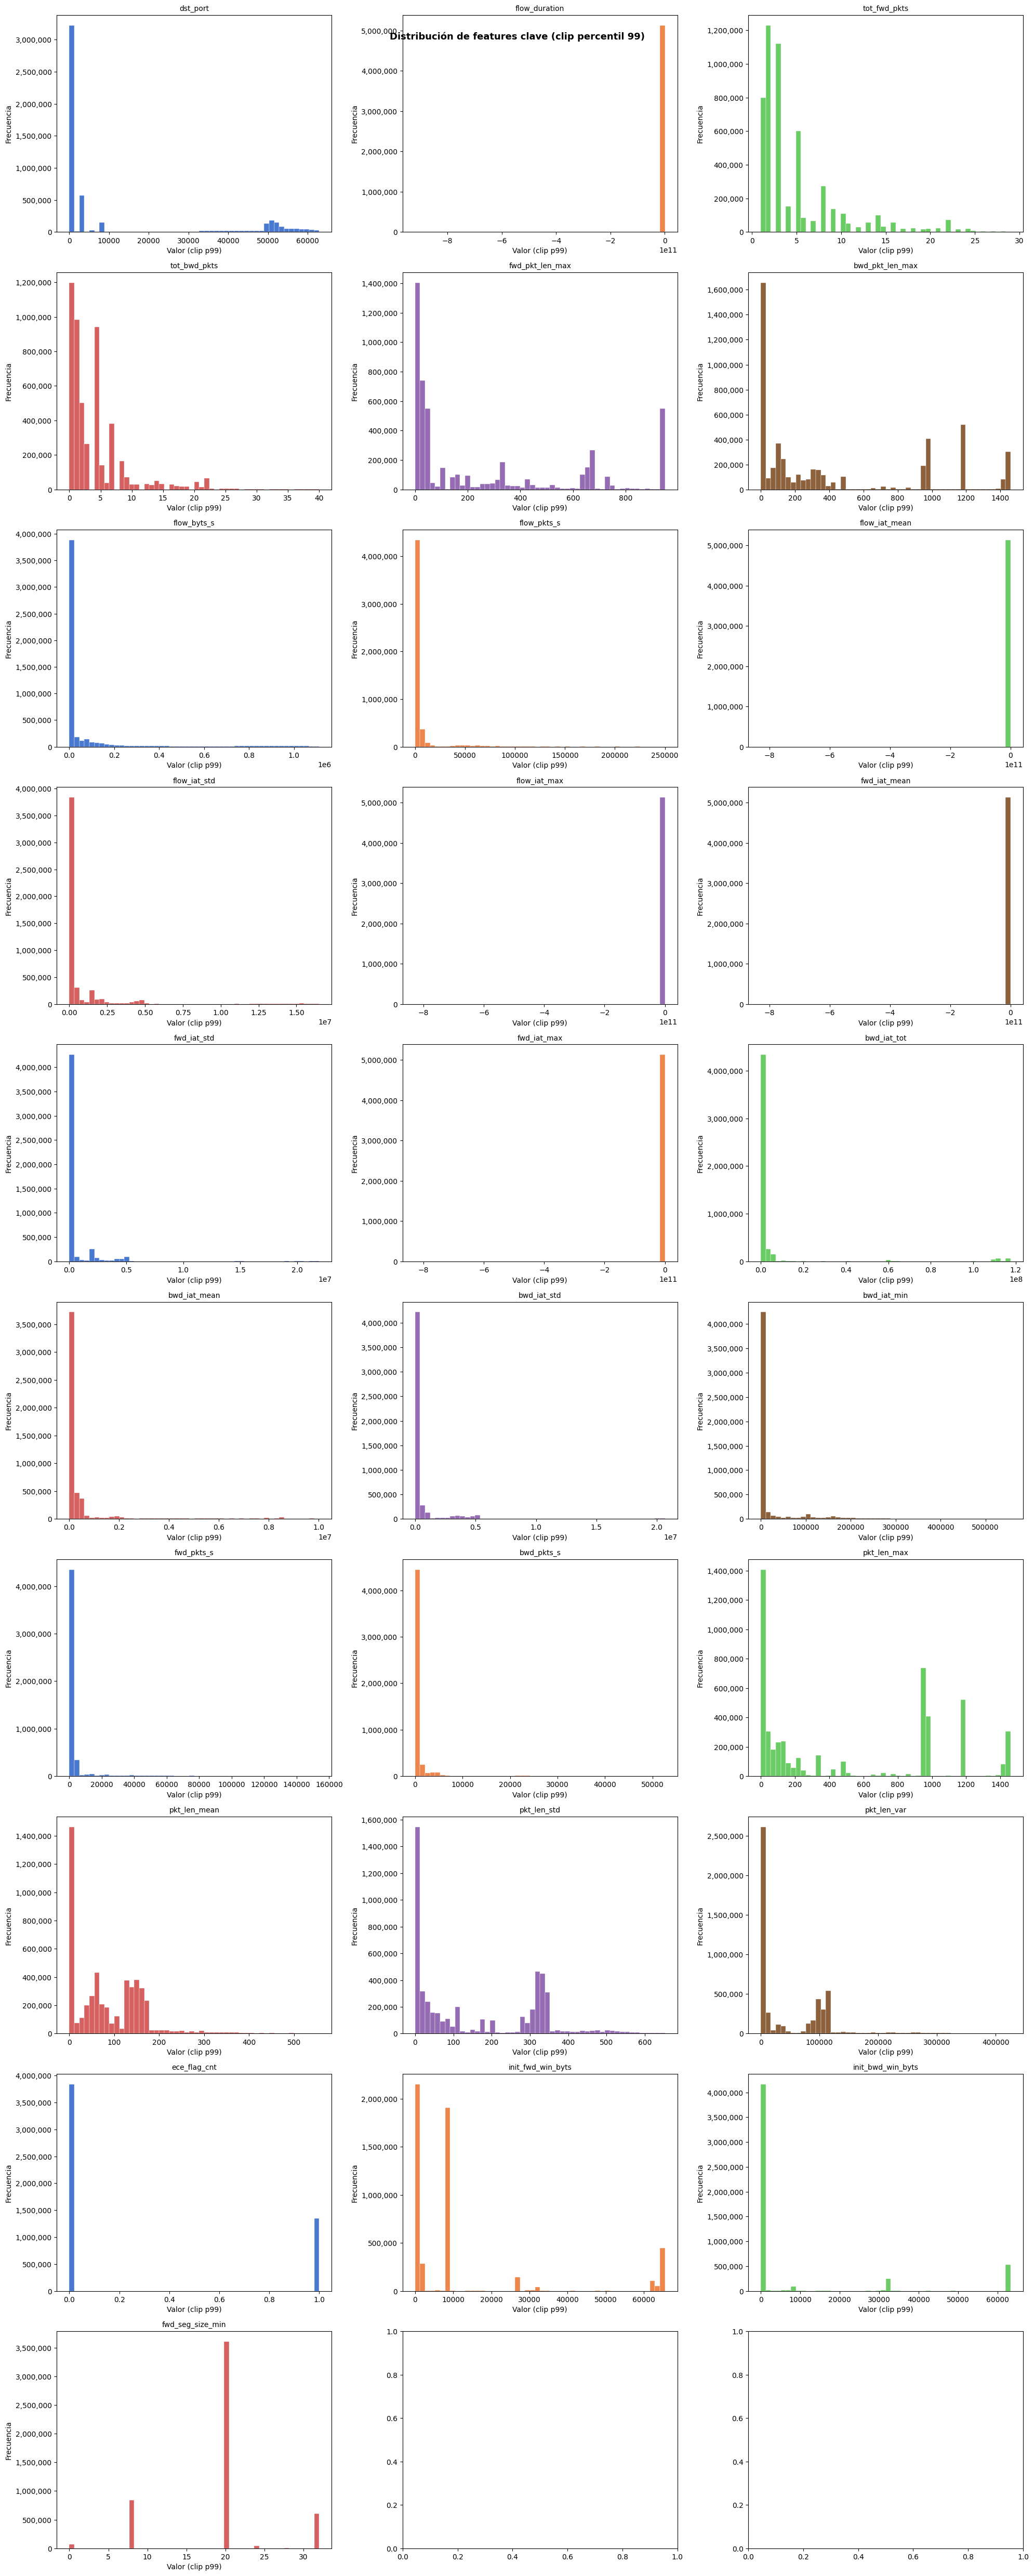

In [26]:
# Distribución de las features 
fig, axes = plt.subplots(10, 3, figsize=(20,50))
axes = axes.flatten()

for i, feat in enumerate(df[selected_features].columns):
    data = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
    # Clip a percentil 99 para visualización
    p99 = data.quantile(0.99)
    data_clipped = data[data <= p99]
    axes[i].hist(data_clipped, bins=50, color=sns.color_palette('muted')[i % 6],
                 edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('Valor (clip p99)')
    axes[i].set_ylabel('Frecuencia')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Distribución de features clave (clip percentil 99)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_features.png', bbox_inches='tight')
plt.show()

### Revisión de valores atípicos

Con la revisión de outliers de las columnas, se puede observar los comportamientos anómalos que presentan los ataques por medio de los valores outliers en comparación con la columna de tráfico de benigno.

Esta revisión de valores atípicos con boxplots demuestra que las características seleccionadas del conjunto de datos cuentan con valores anómalos en el tráfico de red. Columnas como puertos, duración del flujo y el número de paquetes (dst_port, flow_duration, tot_fwd_pkts y tot_bwd_pkts) presentan valores atípicos concentrados en ataques como DoS, DDoS y de fuerza bruta. Este comportamiento también se muestra en las variables de longitud de paquetes, tasas de bytes, paquetes en segundo plano (fwd_pkt_len_max, bwd_pkt_len_max, pkt_len_max, pkt_len_mean, pkt_len_std, pkt_len_var— así como en las tasas de transmisión flow_byts_s, flow_pkts_s, fwd_pkts_s y bwd_pkts_s) y en las estadísticas de tiempos entre llegadas (IAT) como flow_iat_mean, flow_iat_std, flow_iat_max, fwd_iat_mean, fwd_iat_std, fwd_iat_max, bwd_iat_tot, bwd_iat_std, bwd_iat_max y bwd_iat_min, en donde los ataques tienen valores superiores a los del tráfico benigno. Por otra parte, en cuánto las variables internas de los flujos como init_fwd_win_byts, init_bwd_win_byts, fwd_seg_size_min y ece_flag_cnt muestran una gran cantidad de distribuciones en clases de ataques. En conclusión, los resultados dan a comprender que los valores atípicos del conjunto de datos no están relacionado con errores sino más bien asociados a comportamientos maliciosos.


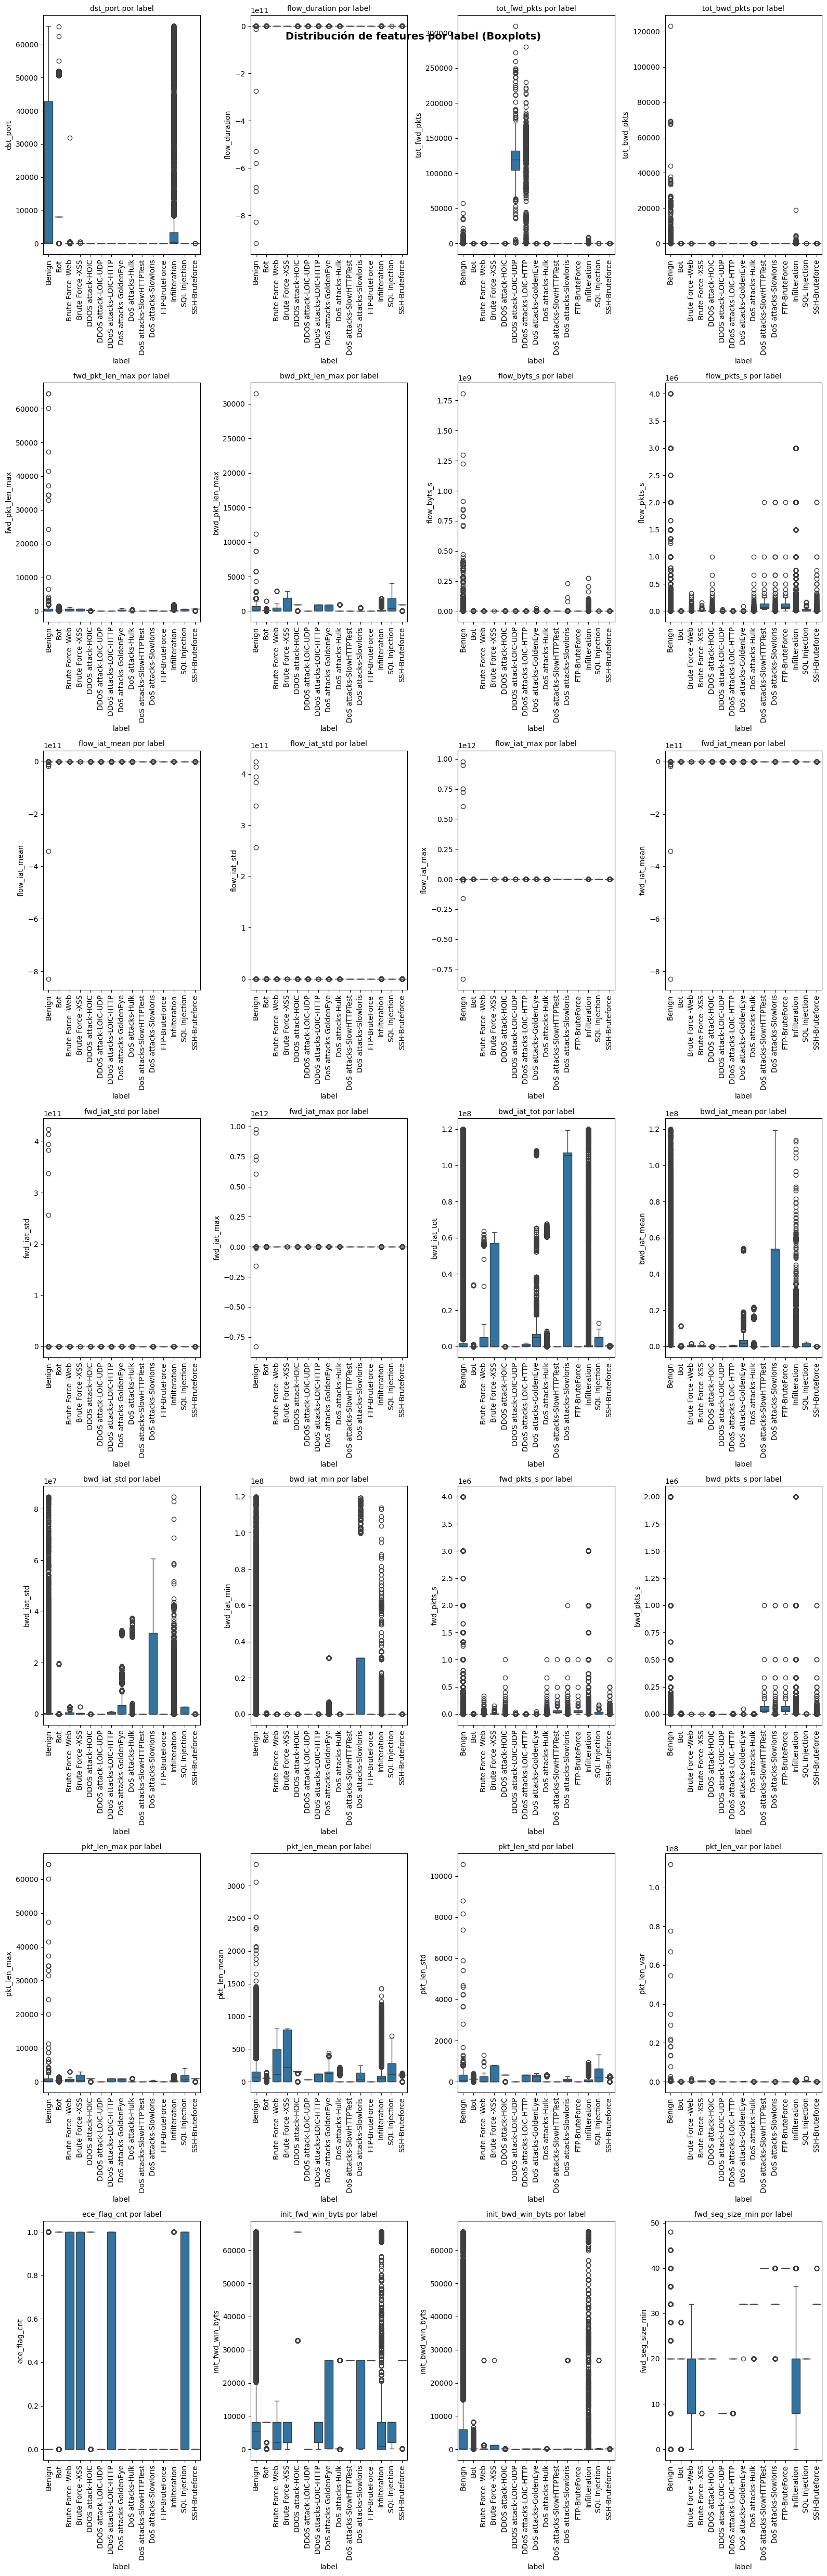

In [27]:
fig, axes = plt.subplots(7, 4, figsize=(16, 50))
axes = axes.flatten()

for i, col in enumerate(selected_features):
    sns.boxplot(data=df, x="label", y=col, ax=axes[i])
    axes[i].set_title(f"{col} por label", fontsize=10)
    axes[i].tick_params(axis='x', rotation=90)

plt.suptitle("Distribución de features por label (Boxplots)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Entrenamiento de los modelos ML

In [28]:
X = df[selected_features].copy()
y = df['label'].copy()
labels = sorted(y.unique())

### No supervisado

In [29]:
# Codificación de variables categóricas
le_dict = {}

le = LabelEncoder()
y_encoded= le.fit_transform(y)

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nX shape: {X_scaled.shape}')
print(f'y shape: {y_encoded.shape}')

unique, counts = np.unique(y_encoded, return_counts=True)

for cls, cnt in zip(unique, counts):
    print(f'Clase {cls}: {cnt:,} muestras')



X shape: (5183021, 28)
y shape: (5183021,)
Clase 0: 3,830,384 muestras
Clase 1: 144,535 muestras
Clase 2: 555 muestras
Clase 3: 228 muestras
Clase 4: 198,861 muestras
Clase 5: 1,730 muestras
Clase 6: 575,364 muestras
Clase 7: 41,406 muestras
Clase 8: 145,199 muestras
Clase 9: 55 muestras
Clase 10: 9,908 muestras
Clase 11: 54 muestras
Clase 12: 140,610 muestras
Clase 13: 84 muestras
Clase 14: 94,048 muestras


Varianza explicada por las 2 primeras componentes: 34.51%
  PC1: 19.60%
  PC2: 14.91%


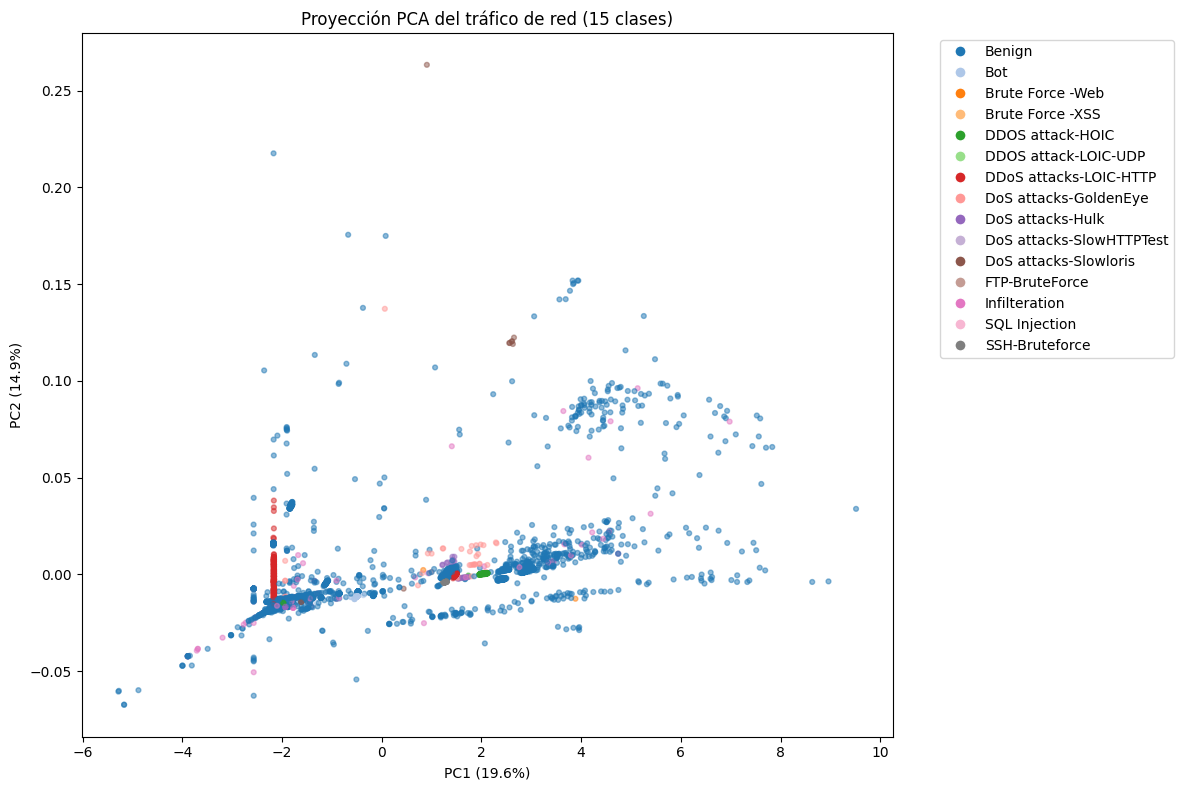

In [30]:
# Aplicar PCA con 2 componentes

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Varianza explicada por las 2 primeras componentes: {pca.explained_variance_ratio_.sum():.2%}')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.2%}')

# Muestra para graficar
sample_idx = np.random.choice(len(X_pca), size=min(5000, len(X_pca)), replace=False)

# Crear un mapa de colores para las 15 clases
num_classes = len(le.classes_)
palette = sns.color_palette("tab20", num_classes)  # paleta grande
colors = [palette[yi] for yi in y_encoded[sample_idx]]

# Gráfico PCA multiclase
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
            c=colors, alpha=0.5, s=12)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Proyección PCA del tráfico de red (15 clases)')

# Leyenda con nombres originales
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=palette[i], markersize=8,
           label=f'{le.classes_[i]}')
    for i in range(num_classes)
]

plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


El PCA solo con dos componentes logra capturar alrededor del 35% de la varianza total, lo cual permite identificar ciertos patrones globales del tráfico de red. Se puede apreciar que algunos tipos de ataques forman agrupamientos compactos, como por ejemplo los de tipo DoS y DDOS, mientras que el tráfico benigno que es el dominante en el conjunto de datos se encuentra muy disperso así como también mezclandose con los ataques, esto debido a la gran variabilidad que presenta esta clase. También este gráfico demuestra la estructura completa y alta dimensionalidad presente en el conjunto de datos, en donde las clases no tienen una separación clara entre los distintos tráficos.  

### Supervisado

#### Bosque aleatorio

In [31]:

# División estratificada: 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [32]:
# Entrenar el bosque aleatorio
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Evaluación
print("=" * 55)
print("  BOSQUE ALEATORIO — Resultados")
print("=" * 55)
print(f"\n  Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\n  Reporte de clasificación:\n")
print(classification_report(
    y_test,
    y_pred_rf,
    labels=labels,
    target_names=labels
))


  BOSQUE ALEATORIO — Resultados

  Exactitud (Accuracy): 0.9736

  Reporte de clasificación:

                          precision    recall  f1-score   support

                  Benign       0.97      1.00      0.98   1149116
                     Bot       1.00      1.00      1.00     43361
        Brute Force -Web       1.00      0.44      0.61       167
        Brute Force -XSS       1.00      0.68      0.81        68
        DDOS attack-HOIC       1.00      1.00      1.00     59658
    DDOS attack-LOIC-UDP       0.82      0.96      0.88       519
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    172609
   DoS attacks-GoldenEye       1.00      1.00      1.00     12422
        DoS attacks-Hulk       1.00      1.00      1.00     43560
DoS attacks-SlowHTTPTest       0.20      0.18      0.19        17
   DoS attacks-Slowloris       1.00      0.99      1.00      2972
          FTP-BruteForce       0.28      0.31      0.29        16
           Infilteration       0.59      0.13  

#### Bosque aleatorio PCA

In [33]:
# División estratificada: 70% entrenamiento, 30% prueba
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

In [34]:
# Entrenar el bosque aleatorio
rf_pca = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_pca.fit(X_train_pca, y_train_pca)

# Predicciones
y_pred_rf_pca = rf_pca.predict(X_test_pca)

# Evaluación
print("=" * 55)
print("  BOSQUE ALEATORIO — Resultados")
print("=" * 55)
print(f"\n  Exactitud (Accuracy): {accuracy_score(y_test_pca, y_pred_rf_pca):.4f}")
print(f"\n  Reporte de clasificación:\n")
print(classification_report(
    y_test_pca,
    y_pred_rf_pca,
    labels=labels,
    target_names=labels
))


  BOSQUE ALEATORIO — Resultados

  Exactitud (Accuracy): 0.9709

  Reporte de clasificación:



c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                          precision    recall  f1-score   support

                  Benign       0.97      1.00      0.98   1149116
                     Bot       1.00      1.00      1.00     43361
        Brute Force -Web       0.92      0.29      0.45       167
        Brute Force -XSS       0.93      0.37      0.53        68
        DDOS attack-HOIC       1.00      1.00      1.00     59658
    DDOS attack-LOIC-UDP       0.77      0.90      0.83       519
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00    172609
   DoS attacks-GoldenEye       0.93      0.90      0.91     12422
        DoS attacks-Hulk       0.99      0.99      0.99     43560
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        17
   DoS attacks-Slowloris       0.99      0.96      0.98      2972
          FTP-BruteForce       0.00      0.00      0.00        16
           Infilteration       0.55      0.09      0.16     42183
           SQL Injection       0.00      0.00      0.00        25
         

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Análisis de resultados

##### Matriz de confusión

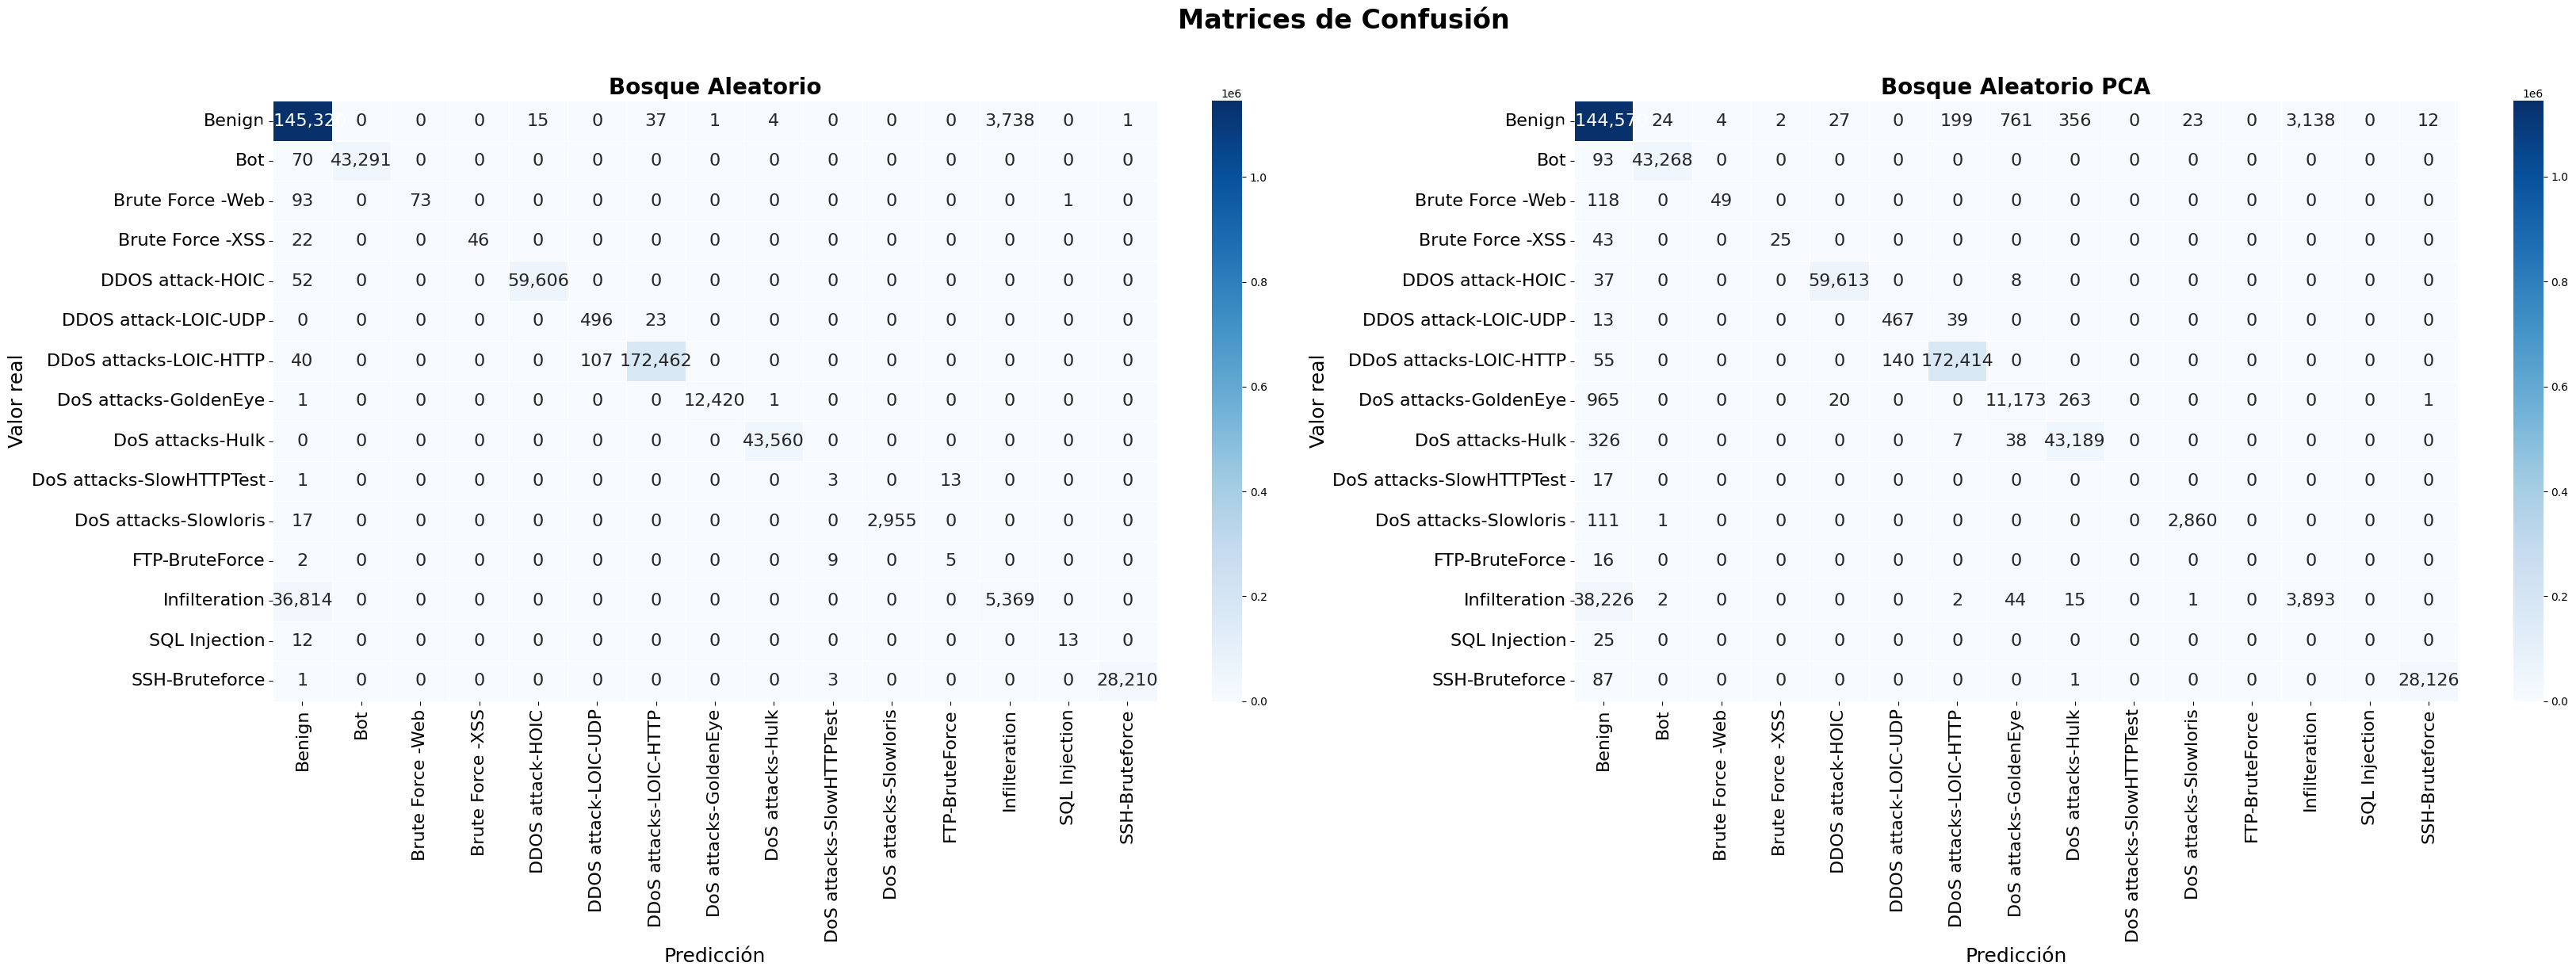

In [35]:
modelos = {
    'Bosque Aleatorio': y_pred_rf,
    'Bosque Aleatorio PCA': y_pred_rf_pca
}

fig, axes = plt.subplots(1, 2, figsize=(34, 12))

for ax, (nombre, y_pred) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, 
                annot=True, 
                fmt=',d', 
                cmap='Blues', ax=ax,
                xticklabels=labels,
                yticklabels=labels,
                linewidths=0.5,
                annot_kws={"size": 16})
    ax.set_title(nombre, fontweight='bold', fontsize=20)
    ax.set_xlabel('Predicción', fontsize=18)
    ax.set_ylabel('Valor real', fontsize=18)
    ax.tick_params(axis='both', labelsize=16)

plt.suptitle('Matrices de Confusión', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()